Student Performance data

In [1]:
d1 = {
    "Study Hrs": [10, 7, 6.5, 6, 5, 4, 1],
    "Grade": [95, 70, 73, 67, 60, 50, 20]
}

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.DataFrame(d1)
df.head()

,Study Hrs,Grade
0,10.0,95
1,7.0,70
2,6.5,73
3,6.0,67
4,5.0,60


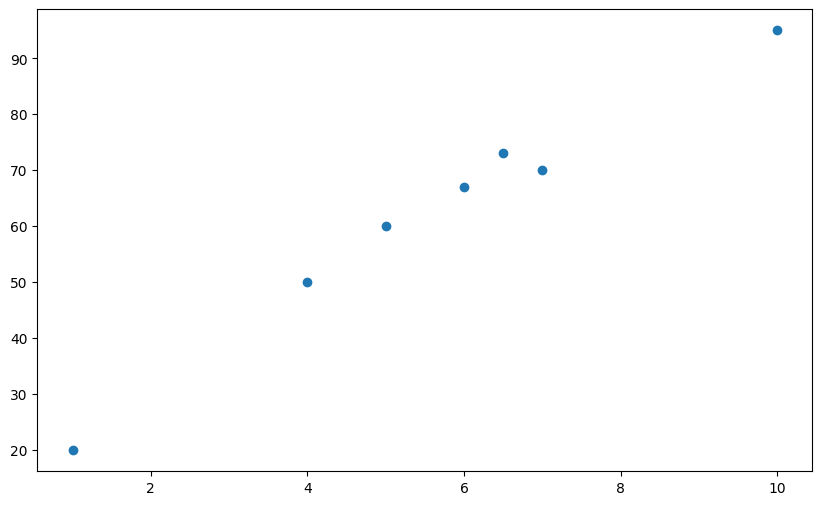

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["Study Hrs"], df["Grade"])

In [7]:
N = len(df["Study Hrs"])
X = df["Study Hrs"]
Y = df["Grade"]

In [8]:
m = (N * sum(X*Y) - sum(X)*sum(Y))/(N*sum(X**2)-sum(X)**2)
c = (sum(Y) - m* sum(X))/N
print(m)
print(c)

8.23728813559322
15.661016949152545


In [11]:
m1,c1 = np.polyfit(X,Y,1)
print(m1)
print(c1)

8.237288135593221
15.66101694915254


In [12]:
x1 = 5.5
y1 = m * x1 + c
print(f"The marks when a student studies for {x1} Hrs is {y1}")

The marks when a student studies for 5.5 Hrs is 60.96610169491525


In [21]:
xm = 6.5
ym = m* xm +c
print(f"The marks when a student studies for {xm} Hrs is {ym}")

The marks when a student studies for 6.5 Hrs is 69.20338983050847


Multiple linear regression

In this section, we will apply multiple linear regression to predict student performance based on various factors.

In [15]:
d2 = {
    "Study Hrs": [10, 7, 6.5, 6, 5, 4, 1],
    "Sleep Hrs": [8,6,5,4,1,2,4],
    "Play Time": [1,2,4,6,8,2,1],
    "Grade": [95, 70, 73, 67, 60, 50, 20]
}

In [16]:
df1 = pd.DataFrame(d2)
df1.head()

,Study Hrs,Sleep Hrs,Play Time,Grade
0,10.0,8,1,95
1,7.0,6,2,70
2,6.5,5,4,73
3,6.0,4,6,67
4,5.0,1,8,60


In [18]:
x1 = df1["Study Hrs"]
x2 = df1["Sleep Hrs"]
x3 = df1["Play Time"]
y = df1["Grade"]

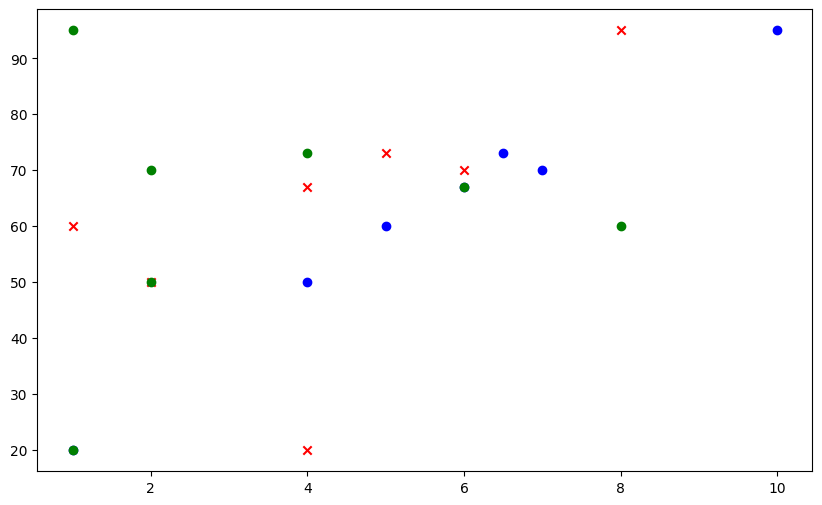

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(x1,y, color='blue', marker='o', label='Study Hrs')
plt.scatter(x2,y, color='red', marker='x', label='Sleep Hrs')
plt.scatter(x3,y, color='green', marker='o', label='Play Time')

In [ ]:
beta, residuals, rank, s = np.linalg.lstsq

Implementation of Linear Regression

In this section, we will implement linear regression to predict student performance based on the available data. We will start by importing the necessary libraries, loading the dataset, and then applying the linear regression model.

Simple linear regression

In this section, we will apply simple linear regression to predict student performance based on a single factor.

In [22]:
df.head()

,Study Hrs,Grade
0,10.0,95
1,7.0,70
2,6.5,73
3,6.0,67
4,5.0,60


In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()
model.fit(df["Study Hrs"],df["Grade"])


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [26]:
X.shape

(7,)

In [27]:
X.ndim

1

In [29]:
X = df["Study Hrs"]
X_reshaped = X.to_frame()

In [30]:
X_reshaped.head()

,Study Hrs
0,10.0
1,7.0
2,6.5
3,6.0
4,5.0


In [31]:
model.fit(X_reshaped, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
print(f"Model Coefficient: {model.coef_[0]}")
print(f"Model Intercept: {model.intercept_}")

Model Coefficient: 8.237288135593223
Model Intercept: 15.661016949152526


In [34]:
predicted = model.predict([[6.5]])

c:\Apps\Python3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [35]:
print(predicted)

[69.20338983]


Multiple linear regression

In this section, we will apply multiple linear regression to predict student performance based on various factors.

In [36]:
df1.head()

,Study Hrs,Sleep Hrs,Play Time,Grade
0,10.0,8,1,95
1,7.0,6,2,70
2,6.5,5,4,73
3,6.0,4,6,67
4,5.0,1,8,60


In [39]:
X_features = df1[['Study Hrs','Sleep Hrs', 'Play Time']]
Y_Grade = df1['Grade']

model1 = LinearRegression()
model1.fit(X_features, Y_Grade)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
print(model1.coef_)
print(model1.intercept_)

[ 8.72960181 -0.86252636  0.49406728]
14.885557762313425


In [43]:
predicted1 = model1.predict([[6.5, 2, 1]])
print(predicted1)


[70.39698412]


c:\Apps\Python3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
